In [2]:
import numpy as np
import pandas as pd 

import spacy
import string
import re
import matplotlib.pyplot as plt

In [3]:
news_df = pd.read_json('small_dataset_articles.json', lines=True)

In [4]:
news_df.info

<bound method DataFrame.info of                                                    link  \
0     https://www.huffingtonpost.com/entry/what-if-w...   
1     https://www.huffingtonpost.comhttp://www.washi...   
2     https://www.huffingtonpost.com/entry/time-runs...   
3     https://www.huffingtonpost.com/entry/one-glimp...   
4     https://www.huffingtonpost.com/entry/mens-swea...   
...                                                 ...   
7995  https://www.huffingtonpost.com/entry/fear-the-...   
7996  https://www.huffingtonpost.com/entry/the-unexp...   
7997  https://www.huffingtonpost.com/entry/homophobi...   
7998  https://www.huffingtonpost.com/entry/poor-slee...   
7999  https://www.huffingtonpost.comhttp://www.newyo...   

                                               headline        category  \
0       What If We Were All Family Generation Changers?          IMPACT   
1           Firestorm At AOL Over Employee Benefit Cuts        BUSINESS   
2     Dakota Access Protesters Arr

In [5]:
news_df.columns

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')

### 1. Data Cleaning and Pre-processing

In [6]:
news_df.isnull()

,link,headline,category,short_description,authors,date
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
7995,False,False,False,False,False,False
7996,False,False,False,False,False,False
7997,False,False,False,False,False,False
7998,False,False,False,False,False,False


In [7]:
news_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7995    False
7996    False
7997    False
7998    False
7999    False
Length: 8000, dtype: bool

In [8]:
top5_categories = news_df['category'].value_counts().head(5)
print(f"Top 5 categories: {top5_categories}")

Top 5 categories: category
POLITICS          1342
WELLNESS           724
ENTERTAINMENT      639
TRAVEL             391
STYLE & BEAUTY     379
Name: count, dtype: int64


### 1.1 Pre-processing - headlines, categories and descriptions

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Point NLTK to local data directory
nltk.data.path.append('./nltk_data')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

text = "Natural Language Processing is fun!"
tokens = word_tokenize(text)
tokens = [lemmatizer.lemmatize(t.lower()) for t in tokens if t.lower() not in stop_words]



In [35]:
import os

nltk_data_path = "./nltk_data"

# Walk through all subfolders
zip_files = []
for root, dirs, files in os.walk(nltk_data_path):
    for fname in files:
        if fname.endswith(".zip"):
            zip_files.append(os.path.join(root, fname))

for z in zip_files:
    os.remove(z)
    print(f"Removed: {z}")


Removed: ./nltk_data/tokenizers/punkt_tab.zip
Removed: ./nltk_data/tokenizers/punkt.zip
Removed: ./nltk_data/corpora/wordnet.zip
Removed: ./nltk_data/corpora/stopwords.zip


In [29]:
# Define the pipeline

# tokenization
def preprocess_text(text, use_lemmatization=True):
    text = str(text) 
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)

# stopwords removal
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.lower() not in stop_words]

# case conversion
    tokens = [token.lower() for token in tokens]

# lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens

In [30]:
headlines_text = news_df['headline'].apply(lambda x: preprocess_text(x, use_lemmatization=True))

In [31]:
category_text = news_df['category']. apply(lambda x: preprocess_text(x, use_lemmatization=True))

In [32]:
description_text = news_df['short_description']. apply(lambda x: preprocess_text(x, use_lemmatization=True))

In [36]:
description_text.head()

0    [wont, create, new, opportunity, well, also, u...
1    [glorious, week, aol, chief, executive, tim, a...
2    [protester, refused, leave, remained, site, th...
3                                                   []
4    [scientist, didnt, know, human, played, game, ...
Name: short_description, dtype: object

### 1.2 Words Frequency

In [37]:
from collections import Counter

In [38]:
headlines_tokens = [token for tokens in headlines_text for token in tokens] 
headlines_counter = Counter(headlines_tokens) 
print(f"Top 10 most common words in Headlines: {headlines_counter.most_common(10)}")

Top 10 most common words in Headlines: [('trump', 514), ('photo', 502), ('new', 346), ('video', 228), ('say', 228), ('day', 217), ('donald', 192), ('u', 190), ('woman', 186), ('get', 171)]


In [39]:
categories_tokens = [token for tokens in category_text for token in tokens] 
categories_counter = Counter(categories_tokens) 
print(f"Top 10 most common words in Categories: {categories_counter.most_common(10)}")

Top 10 most common words in Categories: [('politics', 1342), ('wellness', 724), ('entertainment', 639), ('voice', 477), ('style', 468), ('living', 417), ('travel', 391), ('beauty', 379), ('parenting', 336), ('news', 301)]


In [40]:
description_tokens = [token for tokens in description_text for token in tokens] 
description_counter = Counter(description_tokens) 
print(f"Top 10 most common words in Descriptions: {description_counter.most_common(10)}")

Top 10 most common words in Descriptions: [('one', 525), ('time', 432), ('year', 412), ('new', 402), ('u', 380), ('people', 377), ('like', 351), ('day', 339), ('said', 315), ('life', 300)]


In [41]:
def stats_measures_text(tokens):
    word_counts = Counter(tokens) 
    word_frequencies = list(word_counts.values())
    
    # Calculate mean, variance, and std dev
    mean_freq = np.mean(word_frequencies)
    variance_freq = np.var(word_frequencies)
    std_dev_freq = np.std(word_frequencies)

    return mean_freq, variance_freq, std_dev_freq

In [42]:
mean_freq, variance_freq, std_dev_freq = stats_measures_text(headlines_tokens)

print(f"Headlines - Mean Frequency: {mean_freq}")
print(f"Headlines - Variance Frequency: {variance_freq}")
print(f"Headlines - Standard Deviation: {std_dev_freq}")

Headlines - Mean Frequency: 4.396160699821805
Headlines - Variance Frequency: 159.46455354099888
Headlines - Standard Deviation: 12.627927523588298


In [43]:
mean_freq, variance_freq, std_dev_freq = stats_measures_text(description_tokens)

print(f"Descriptions - Mean Frequency: {mean_freq}")
print(f"Descriptions - Variance Frequency: {variance_freq}")
print(f"Descriptions - Standard Deviation: {std_dev_freq}")

Descriptions - Mean Frequency: 5.379848307331812
Descriptions - Variance Frequency: 289.67380738896435
Descriptions - Standard Deviation: 17.01980632642347


In [44]:
from wordcloud import WordCloud, STOPWORDS
from nltk.probability import FreqDist
from PIL import Image

In [45]:
# join tokens as strings
text_headlines = " ".join(headlines_tokens)
text_description = " ".join(description_tokens)

In [46]:
wordcloud = WordCloud(min_font_size=8, 
                      max_font_size=80, 
                      width=1500, height=1000, 
                      max_words=1000, 
                      background_color="white").generate(text_headlines)

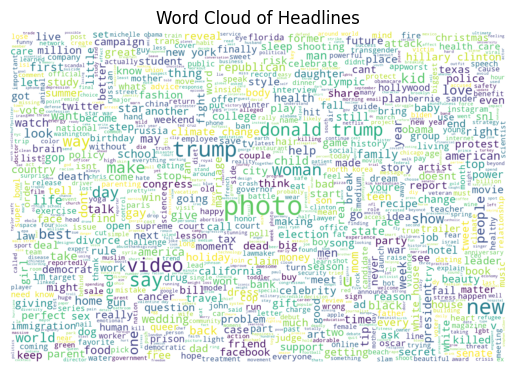

In [47]:
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Word Cloud of Headlines")
plt.axis("off")
plt.show()

In [48]:
df = pd.DataFrame({
    "headline": text_headlines,
    "description": text_description,
    "category": news_df["category"],
})

In [50]:
import pickle

# Example structure: dictionary with tokens and categories
data = {
    "headlines_tokens": headlines_tokens,
    "description_tokens": description_tokens,
    "categories": news_df["category"].tolist()  # convert pandas Series to list
}

with open("tokens.pkl", "wb") as f:
    pickle.dump(data, f)


TypeError: '_io.BufferedWriter' object cannot be interpreted as an integer

### 2. Bag of Words

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

In [46]:
corpus=[" ".join(tokens) for tokens in text_headlines]

In [47]:
vectorizer = CountVectorizer()
model_bow = vectorizer.fit_transform(corpus)

ValueError: empty vocabulary; perhaps the documents only contain stop words

In [ ]:
print(vectorizer.get_feature_names_out())
# Output: ['and', 'cat', 'chased', 'dog', 'mat', 'on', 'played', 'sat', 'the']